# Finding parallel fifths/octaves and unresolved open chords

This tutorial shows how to take a four-part chorale (e.g. an SATB hymn exported
from notation software, or one of the Bach chorales in the corpus) and
automatically flag two classic part-writing problems:

1. **Parallel perfect fifths and octaves** between any pair of voices.
2. **Chords with no third** (bare octaves/open fifths) that *never acquire a
   third before the bass moves on* — i.e. an incomplete sonority that does not
   resolve in place.

Everything here uses only public music21 API: `tree` timespans +
`voiceLeading.VoiceLeadingQuartet` for the parallels, and `chordify` for the
missing-third check.

## 0. One voice per part — the crucial first step

The voice-leading tools compare *parts*. They line up the notes sounding in
part A against the notes sounding in part B and ask how each pair moves.

That only works if **each part contains a single melodic line**. Many real
scores don't: an SATB hymn is often engraved on two staves with *two voices per
staff* (Soprano+Alto on the treble staff, Tenor+Bass on the bass staff). If you
feed that to the analyzer as-is, it has no way to know which note belongs to
which line, and it produces nonsense pairings.

`Score.voicesToParts()` fixes this in one call: it returns a new score with every
voice promoted to its own part. It is a no-op for parts that already hold a
single line — so running it is safe whether you start from a Bach chorale
(already four separate parts) or a two-staff hymn.

In [1]:
from music21 import converter, corpus, tree, note, stream

# a two-staff / two-voice-per-staff hymn becomes four single-line parts:
# demo = converter.parse('myChorale.musicxml')
# demo.voicesToParts()   # -> Score with one voice per Part

To load *your own* chorale, point `converter.parse` at the file:

```python
score = converter.parse('/path/to/myChorale.musicxml')
```

For a runnable, reproducible example we'll use the chorale **bwv177** from the
corpus (`Ich ruf zu dir, Herr Jesu Christ`).

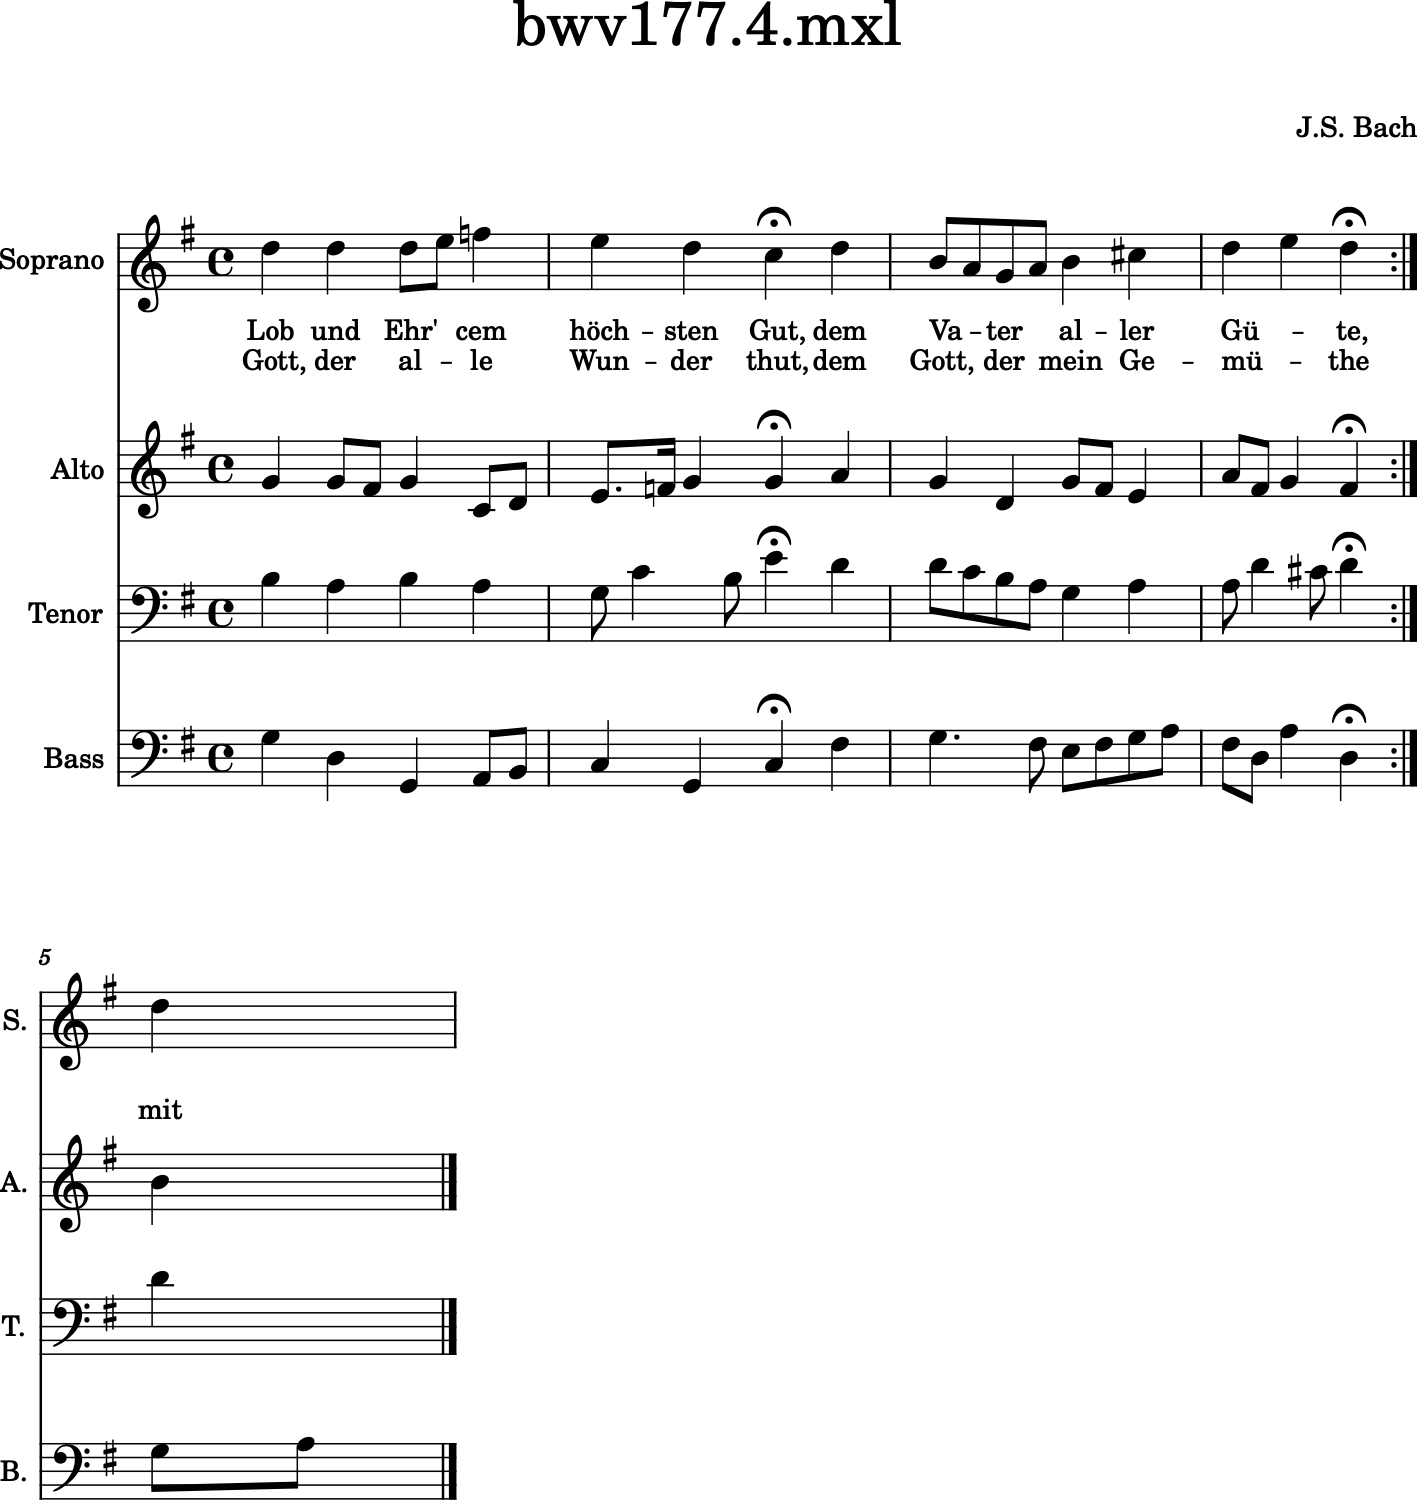

In [2]:
score = corpus.parse('bach/bwv177')
score.measures(1, 4).show()  # comment out if you're running headless

## 1. Parallel fifths and octaves

The engine is `tree.fromStream.asTimespans`, which turns the score into a tree
of overlapping note-spans. Walking its **verticalities** (the simultaneities)
and calling `getAllVoiceLeadingQuartets()` on each one hands you a
`VoiceLeadingQuartet` for every pair of voices moving from this slice to the
next.

A `VoiceLeadingQuartet` knows how to classify itself:

* `parallelFifth()` — both voices a perfect fifth apart, moving in parallel.
* `parallelOctave()` — same, a perfect octave (or unison) apart.
* `parallelUnison()`, `hiddenFifth()`, `hiddenOctave()`, `motionType()` … and more.

Note the `score.voicesToParts()` call up front — that's the one-voice-per-part
step from section 0. We de-duplicate the results, because one sustained note
makes the same quartet show up under several consecutive verticalities.

In [3]:
def findParallels(score):
    # Return a list of (measureNumber, 'P5'|'P8', VoiceLeadingQuartet) for every
    # parallel perfect fifth or octave between any pair of voices.
    sc = score.voicesToParts()  # one melodic line per part
    scoreTree = tree.fromStream.asTimespans(sc, flatten=True, classList=(note.Note,))
    seen = set()
    results = []
    for vert in scoreTree.iterateVerticalities():
        for vlq in vert.getAllVoiceLeadingQuartets(includeRests=False):
            if vlq.parallelFifth():
                kind = 'P5'
            elif vlq.parallelOctave():
                kind = 'P8'
            else:
                continue
            m = vlq.v1n1.measureNumber
            key = (m, kind, vlq.v1n1.nameWithOctave, vlq.v2n1.nameWithOctave)
            if key in seen:
                continue
            seen.add(key)
            results.append((m, kind, vlq))
    return results


def showParallels(score):
    results = findParallels(score)
    if not results:
        print('No parallel fifths or octaves found.')
        return
    for m, kind, vlq in results:
        print(f'm{m}: {kind}  '
              f'{vlq.v1n1.nameWithOctave}->{vlq.v1n2.nameWithOctave}  with  '
              f'{vlq.v2n1.nameWithOctave}->{vlq.v2n2.nameWithOctave}')


showParallels(score)

No parallel fifths or octaves found.


A clean Bach chorale reports nothing — which is exactly the point: the
tool is quiet when the writing is correct, so any output is worth a look.

To prove the detector actually fires, here is a deliberate parallel fifth:
two voices a fifth apart (C4/G4) both stepping up.

In [4]:
bad = stream.Score()
top = stream.Part()
bottom = stream.Part()
for n in ('G4', 'A4'):
    top.append(note.Note(n))
for n in ('C4', 'D4'):
    bottom.append(note.Note(n))
bad.insert(0, top)
bad.insert(0, bottom)

showParallels(bad)

mNone: P5  G4->A4  with  C4->D4


### Reading the results

Each line names the measure, the interval class (`P5`/`P8`), and the two voices'
motion. `vlq.v1n1`/`v1n2` are the first voice's *from* and *to* notes; `v2n1`/
`v2n2` the second voice's. From there you can jump to the score and look.

A few honest caveats:

* It compares **every** pair of voices, so an intentional octave doubling
  (common on a final chord, or bass doubling the melody) is reported too. Judge
  each hit musically.
* `hiddenFifth()` / `hiddenOctave()` (direct/exposed perfect intervals reached by
  similar motion into an outer voice) are a separate question — swap them in if
  you want to screen for those as well.
* Voices that cross or rest can confuse the pairing; for standard homophonic
  chorale writing it is reliable.

## 2. Open chords (no third) that don't resolve before the bass moves

A bare fifth or octave is fine as a passing color *if a third arrives over the
same bass note before the harmony changes*. It's the open sonority that sits
there and then **moves on with the bass still thirdless** that we want to flag.

`chordify()` collapses all the parts into a running sequence of chords — one new
chord whenever any voice changes — which is exactly the granularity we need.
For each chord, `chord.third` is `None` when no third above the root is present.

The strategy: group consecutive chords that share the same bass pitch class. If a
whole bass-group goes by without any of its chords ever having a third, the first
open chord in that group is flagged.

In [5]:
def findUnresolvedOpenChords(score):
    # Return a list of (measureNumber, chord) for open (thirdless) sonorities
    # that never gain a third before the bass note changes.
    chordified = score.chordify()
    results = []
    group = []
    prevBass = None

    def flush(group):
        if not group:
            return
        if any(c.third is not None for c in group):
            return  # a third arrived over this bass -- fine
        # only genuine chords (more than one pitch class), not a lone note or a
        # pure octave doubling of a single pitch
        openChords = [c for c in group
                      if c.third is None and len({p.name for p in c.pitches}) > 1]
        if not openChords:
            return
        c = openChords[0]
        meas = c.getContextByClass(stream.Measure)
        results.append((meas.number if meas is not None else None, c))

    for c in chordified.recurse().getElementsByClass('Chord'):
        bassName = c.bass().name
        if bassName != prevBass:
            flush(group)
            group = []
            prevBass = bassName
        group.append(c)
    flush(group)
    return results


def showUnresolvedOpenChords(score):
    results = findUnresolvedOpenChords(score)
    if not results:
        print('No unresolved thirdless chords found.')
        return
    for m, c in results:
        pitches = ' '.join(p.nameWithOctave for p in c.pitches)
        print(f'm{m}: [{pitches}]  bass={c.bass().name}  (no third before bass moves)')


showUnresolvedOpenChords(score)

m6: [G3 D4 D5 F#5]  bass=G  (no third before bass moves)
m7: [D3 C4 G4 G5]  bass=D  (no third before bass moves)
m7: [C3 D4 G4 D5]  bass=C  (no third before bass moves)


This time the chorale is *not* silent — bwv177 produces three hits around
mm. 6–7. They're worth understanding, because they expose the rule's main blind
spot:

```
m6: [G3 D4 D5 F#5]  bass=G   (no third before bass moves)
m7: [D3 C4 G4 G5]   bass=D   (no third before bass moves)
m7: [C3 D4 G4 D5]   bass=C   (no third before bass moves)
```

None of these is a real error. In every case the **bass note is a passing tone**
— in m7 the bass walks straight down E–D–C–B in eighth-notes — so for one eighth
the sonority over that passing bass happens to lack a third, then the bass steps
on. (The m6 hit is the same story with an added passing F♯ in the soprano.) A
momentary open chord under a passing bass is perfectly idiomatic. The takeaway:
like the parallels check, this flags *candidates*, and passing/neighbor motion is
the usual source of false positives (see "Tuning the rule" below).

To see a hit that really is a problem, here's a constructed progression: an open
fifth on D (D3–D4–A4, no F) held while the bass stays on D, then the bass jumps
to G — the third never came, so the D chord is correctly flagged.

In [6]:
openExample = stream.Score()
parts = [stream.Part() for _ in range(3)]
for row in [('A4', 'D4', 'D3'),   # open fifth on D, no third
            ('A4', 'D4', 'D3'),   # still open, bass unchanged
            ('B4', 'G4', 'G3')]:  # bass moves to G (full triad)
    for part, name in zip(parts, row):
        part.append(note.Note(name))
for part in parts:
    openExample.insert(0, part)

showUnresolvedOpenChords(openExample)

mNone: [D3 D4 A4]  bass=D  (no third before bass moves)


### Tuning the rule

* Grouping by **bass pitch class** (`c.bass().name`) treats a bass octave leap as
  "the bass moving." If you'd rather allow the third to arrive over a bass that
  merely changes register, group by `c.bass().nameWithOctave` instead.
* `chord.third` checks for a third *above the chord's root*, which is the
  textbook reading of "the chord has no third." For more exotic sonorities you
  may want `chord.isTriad()` / `chord.isSeventh()` or an interval-vector test.
* Passing and neighbor tones — in the bass *or* an upper voice — can momentarily
  create or hide a third (this is exactly what produced the three harmless mm. 6–7
  hits above). For strict checking, reduce non-chord tones first, or ignore hits
  whose bass note lasts only a fraction of a beat.

## Putting it together

```python
score = converter.parse('myChorale.musicxml')
showParallels(score)
showUnresolvedOpenChords(score)
```

Both functions return plain lists, so you can also feed the offending
`VoiceLeadingQuartet`s / `Chord`s back into a `.show()` highlight, a count, or a
batch report over a whole folder of student exercises.